# NAFNet Training - Gaussian Noise Removal

In [1]:
# Control variable: set to True to skip training and only load existing results
SKIP_TRAINING = False

import warnings
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import cv2

# Windows/Jupyter stability: avoid OpenCV internal thread contention with DataLoader
cv2.setNumThreads(0)

from src.degradations import generate_degraded_dataset_auto
from src.losses.loss_factory import get_criterion
from src.models.nafnet import NAFNet
from src.training import get_dataloaders, run_training
from src.utils import (
    load_checkpoint,
    plot_image_comparison,
    plot_inference_results,
    plot_training_curves,
    print_training_summary,
    setup_or_resume_experiment,
    resume_training,
    download_div2k_dataset,
)
from src.evaluation import ImageRestorationEvaluator

warnings.filterwarnings("ignore")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.set_float32_matmul_precision('high')


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3070
CUDA memory: 8.59 GB


## 1. Training Configuration

In [2]:
config = {
    # 1. NON riprendiamo il training vecchio, ne iniziamo uno "fresco" per il fine-tuning
    "resume_from_checkpoint": False,  # <-- Rimetti a False
    "resume_experiment": "latest",
    # 2. Configurazione Fine-Tuning (Poche epoche, Learning Rate microscopico)
    "batch_size": 32,                 
    "num_epochs": 50,                 # Bastano 50 epoche
    "learning_rate": 2e-5,            # <-- Drasticamente più basso! (Da 1e-3 a 2e-5)
    "weight_decay": 0.0,
    # Data - Manteniamo i tempi veloci
    "patch_size": 128,              
    "patches_per_image": 1,         
    "num_workers": 0,
    # Model - Invariato (La NAFNet deve essere identica)
    "model_name": "nafnet",
    "naf_width": 64,
    "naf_middle_blocks": 1,
    "naf_enc_blocks": (1, 1, 2, 8),
    "naf_dec_blocks": (1, 1, 1, 1),
    "naf_dw_expand": 2,
    "naf_ffn_expand": 2,
    "naf_drop_out_rate": 0.0,
    "naf_drop_path_rate": 0.05,     
    # 3. CAMBIO LOSS: Aggiungiamo SSIM come guida morbida
    "loss_type": "charbonnier",      
    "loss_alpha": 0.95,              
    "loss_beta": 0.05,               
    # Degradation
    "degradation_type": "gaussian_noise",
    "noise_sigma": 100.0,
    # Optimization
    "scheduler": "cosine",
    "warmup_epochs": 2,             # Warmup molto breve
    "min_lr": 1e-7,                 # Può scendere fino a zero spaccato
    "gradient_clip": 1.0,
    # Early stopping
    "patience": 15, 

    # Checkpoints
    "save_every": 10,
    "val_every": 1,

    # Mixed Precision - Accelleratore
    "use_amp": True,
    "perf_log_every": 5,
    "perf_sync_cuda": False,

    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}


## 2. Setup Experiment Directories

In [3]:
exp_dir, checkpoints_dir, samples_dir, logs_dir = setup_or_resume_experiment(
    model_name=config["model_name"],
    degradation="gaussian",
    config=config,
    resume_from_checkpoint=config["resume_from_checkpoint"],
    resume_experiment=config["resume_experiment"],
    custom_name="nafnet_gaussian",
)

print(f"Experiment directory: {exp_dir}")


📁 Experiment: 20260331_160741_nafnet_gaussian
Experiment directory: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian


## 3. Setup TensorBoard

In [4]:
writer = SummaryWriter(log_dir=logs_dir)

print(f"TensorBoard logs: {logs_dir}")
print(f"Run: tensorboard --logdir {logs_dir.absolute()}")

TensorBoard logs: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\logs
Run: tensorboard --logdir i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\logs


## 4. Prepare Datasets

In [5]:
# Download raw datasets if needed
download_div2k_dataset()

print("=" * 80)
print("Generating/Loading Degraded Datasets")
print("=" * 80)
print(f"Degradation: Gaussian Noise (sigma={config['noise_sigma']})")

# Training dataset
train_degraded_dir, train_clean_dir = generate_degraded_dataset_auto(
    dataset_split="DIV2K_train_HR",
    degradation_type="gaussian_noise",
    noise_sigma=config["noise_sigma"],
    seed=config["seed"],
)

# Validation dataset
val_degraded_dir, val_clean_dir = generate_degraded_dataset_auto(
    dataset_split="DIV2K_valid_HR",
    degradation_type="gaussian_noise",
    noise_sigma=config["noise_sigma"],
    seed=config["seed"],
)

config["train_degraded_dir"] = str(train_degraded_dir)
config["train_clean_dir"] = str(train_clean_dir)
config["val_degraded_dir"] = str(val_degraded_dir)
config["val_clean_dir"] = str(val_clean_dir)

print("=" * 80)
print("Datasets ready")
print("=" * 80)

Generating/Loading Degraded Datasets
Degradation: Gaussian Noise (sigma=100.0)
Datasets ready


## 5. Create Dataloaders

In [6]:
train_loader, val_loader = get_dataloaders(
    train_degraded_dir=config["train_degraded_dir"],
    train_clean_dir=config["train_clean_dir"],
    val_degraded_dir=config["val_degraded_dir"],
    val_clean_dir=config["val_clean_dir"],
    batch_size=config["batch_size"],
    patch_size=config["patch_size"],
    patches_per_image=config["patches_per_image"],
    num_workers=config["num_workers"],
)

print(f"Batches per epoch: {len(train_loader)} train, {len(val_loader)} val")

Loaded 800 valid images for train set
Loaded 100 valid images for val set
📊 Dataset Summary:
   Train: 800 patches from 800 images
   Val:   100 patches from 100 images
   Batch size: 32
   Patch size: 128x128
Batches per epoch: 25 train, 4 val


## 6. Visualize Sample Batch

Batch shapes:
   Degraded: torch.Size([32, 3, 128, 128])
   Clean: torch.Size([32, 3, 128, 128])
   Range: [-1.000, 1.000]


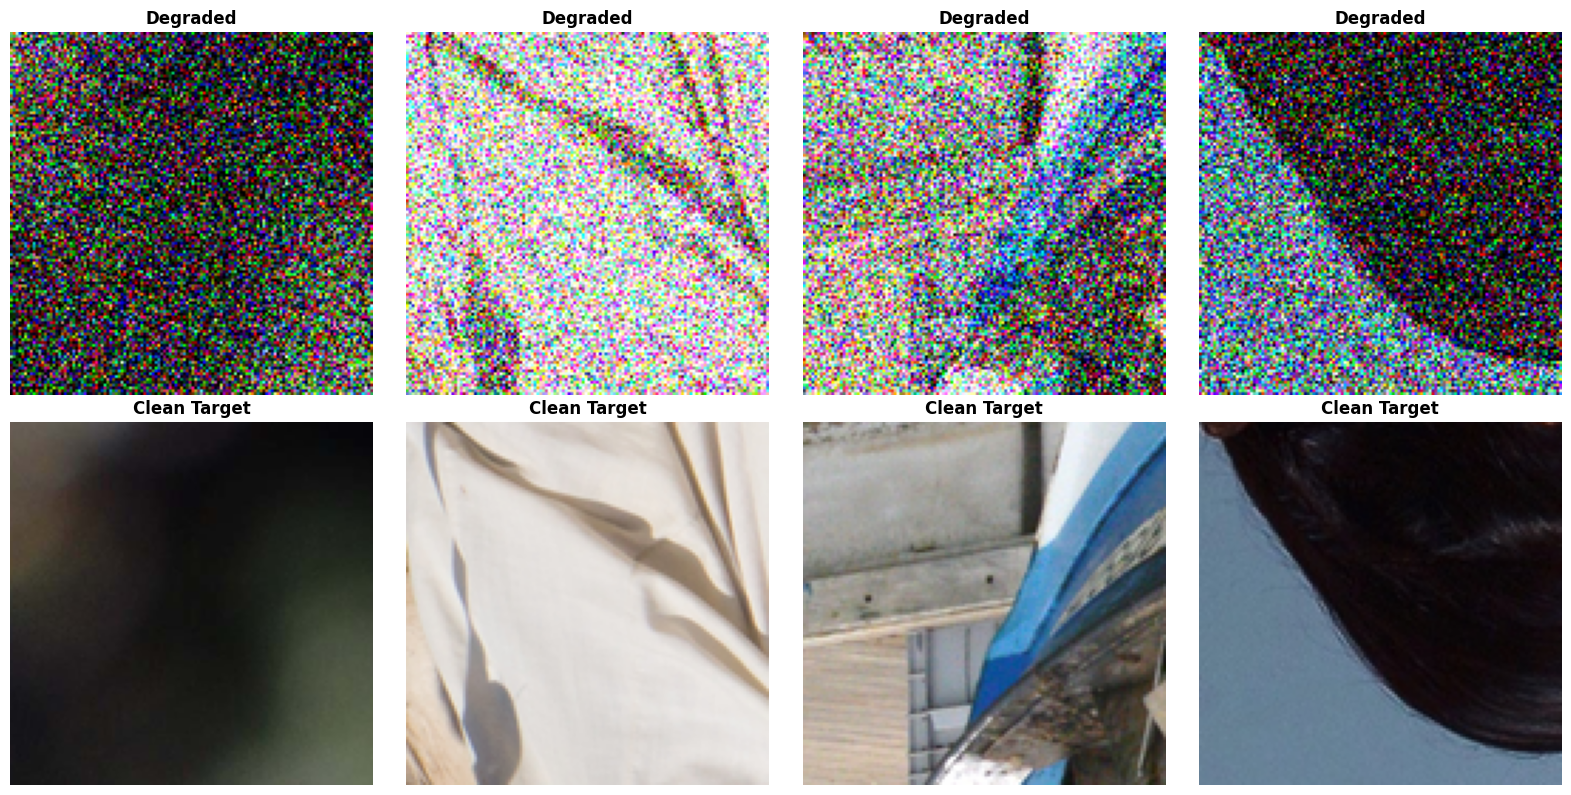

Sample batch saved to i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\samples\training_samples.png


In [7]:
degraded_batch, clean_batch = next(iter(train_loader))

print("Batch shapes:")
print(f"   Degraded: {degraded_batch.shape}")
print(f"   Clean: {clean_batch.shape}")
print(f"   Range: [{degraded_batch.min():.3f}, {degraded_batch.max():.3f}]")

plot_image_comparison(
    degraded_batch=degraded_batch,
    clean_batch=clean_batch,
    n_samples=4,
    save_path=samples_dir / "training_samples.png",
)

print(f"Sample batch saved to {samples_dir / 'training_samples.png'}")

## 7. Initialize Model, Loss, Optimizer

In [8]:
model = NAFNet(
    img_channel=3,
    width=config["naf_width"],
    middle_blk_num=config["naf_middle_blocks"],
    enc_blk_nums=config["naf_enc_blocks"],
    dec_blk_nums=config["naf_dec_blocks"],
    dw_expand=config["naf_dw_expand"],
    ffn_expand=config["naf_ffn_expand"],
    drop_out_rate=config["naf_drop_out_rate"],
    drop_path_rate=config.get("naf_drop_path_rate", 0.0), # <- BUG FIXATO QUI
).to(config["device"])

print("Model: NAFNet")
print(f"   Parameters: {model.get_num_params():,}")
print(f"   Device: {config['device']}")

criterion = get_criterion(config).to(config["device"])

optimizer = optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
)

scheduler = None
if config["scheduler"] == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["num_epochs"] - config["warmup_epochs"],
        eta_min=config["min_lr"],
    )

start_epoch = 0
initial_best_loss = float("inf")
initial_best_epoch = 0
initial_history = None

if config["resume_from_checkpoint"]:
    (
        checkpoint_info,
        start_epoch,
        initial_history,
        exp_dir,
        initial_best_epoch,
    ) = resume_training(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        experiment_path=config["resume_experiment"],
        model_name=config["model_name"],
        degradation="gaussian",
        device=config["device"],
    )
    initial_best_loss = checkpoint_info["metrics"].get("val", {}).get("loss", float("inf"))


Model: NAFNet
   Parameters: 31,317,955
   Device: cuda
📐 Loss: Charbonnier (α=0.95, β=0.05)


# FINE-TUNING: carica solo i pesi del modello (NON optimizer e scheduler)
from src.utils.checkpoints import load_pretrained_model

load_pretrained_model(
    model=model,
    experiment_path="20260328_190320_nafnet_gaussian",   # ← timestamp Fase 1
    model_name=config["model_name"],
    degradation="gaussian",
    device=config["device"],
    checkpoint_name="best_model.pth",
)

print("✅ Pesi caricati dall'epoca 47 (val_loss=0.0650)")
print(f"   Optimizer: FRESCO con lr={config['learning_rate']:.0e}")



In [13]:
# FINE-TUNING ENABLED: carica solo i pesi del modello (NON optimizer e scheduler)
from src.utils.checkpoints import load_pretrained_model

# Carica in automatico il model_best.pth dall'esperimento specifico
load_pretrained_model(
    model=model,
    experiment_path="20260331_121230_fork_nafnet_gaussian",
    model_name=config["model_name"],
    degradation="gaussian",
    device=config["device"],
    checkpoint_name="best_model.pth",
)

print(f"✅ Pesi di Fase 1 caricati correttamente")
print(f"   Optimizer: FRESCO con lr={config['learning_rate']:.0e}")


📥 Loading checkpoint from: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_121230_fork_nafnet_gaussian\checkpoints\best_model.pth
✅ Loaded model from epoch 50 (loss: 0.05952449329197407)
✅ Pesi di Fase 1 caricati correttamente
   Optimizer: FRESCO con lr=2e-05


In [14]:
import time

print("=" * 80)
print("Smoke test: first batch + single forward pass")
print("=" * 80)

t0 = time.time()
degraded_batch, clean_batch = next(iter(train_loader))
t1 = time.time()
print(f"First batch loaded in {t1 - t0:.2f}s")

degraded_batch = degraded_batch.to(config["device"])
clean_batch = clean_batch.to(config["device"])

model.eval()
with torch.no_grad():
    t2 = time.time()
    _ = model(degraded_batch)
    if config["device"] == "cuda":
        torch.cuda.synchronize()
    t3 = time.time()
print(f"Single forward pass in {t3 - t2:.2f}s")
print("Smoke test OK")

Smoke test: first batch + single forward pass
First batch loaded in 2.86s
Single forward pass in 0.49s
Smoke test OK


In [15]:
print("=" * 80)
print("Smoke test: single train-step timing (forward + loss + backward)")
print("=" * 80)

model.train()
optimizer.zero_grad(set_to_none=True)

t0 = time.time()

if config["use_amp"] and config["device"] == "cuda":
    scaler_dbg = torch.amp.grad_scaler.GradScaler()
    with torch.amp.autocast_mode.autocast(device_type="cuda"):
        output = model(degraded_batch)
        loss, metrics = criterion(output, clean_batch)
    if config["device"] == "cuda":
        torch.cuda.synchronize()
    t1 = time.time()
    scaler_dbg.scale(loss).backward()
else:
    output = model(degraded_batch)
    loss, metrics = criterion(output, clean_batch)
    if config["device"] == "cuda":
        torch.cuda.synchronize()
    t1 = time.time()
    loss.backward()

if config["device"] == "cuda":
    torch.cuda.synchronize()
t2 = time.time()

# Clear grads so this diagnostic step does not affect actual training
optimizer.zero_grad(set_to_none=True)

print(f"Forward+loss: {t1 - t0:.2f}s")
print(f"Backward only: {t2 - t1:.2f}s")
print(f"Total timed step: {t2 - t0:.2f}s")
print(f"Loss: {metrics['total']:.4f}")
print("Train-step timing smoke test OK")

Smoke test: single train-step timing (forward + loss + backward)
Forward+loss: 1.36s
Backward only: 2.45s
Total timed step: 3.81s
Loss: 0.0836
Train-step timing smoke test OK


## 8. Training Loop

In [16]:
if not SKIP_TRAINING:
    history, best_info = run_training(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=config["device"],
        num_epochs=config["num_epochs"],
        checkpoints_dir=checkpoints_dir,
        writer=writer,
        warmup_epochs=config["warmup_epochs"],
        learning_rate=config["learning_rate"],
        patience=config["patience"],
        save_every=config["save_every"],
        val_every=config["val_every"],
        gradient_clip=config["gradient_clip"],
        start_epoch=start_epoch,
        initial_best_loss=initial_best_loss,
        initial_best_epoch=initial_best_epoch,
        initial_history=initial_history,
        use_amp=config["use_amp"],
        config=config
    )

    best_epoch = best_info["best_epoch"]
    best_val_loss = best_info["best_val_loss"]
    print(f"Training history saved to {exp_dir / 'history.json'}")
else:
    print("Loading existing history (SKIP_TRAINING=True)")
    from src.utils.experiment import load_training_history

    history = load_training_history(exp_dir)
    if history.get("val_loss"):
        val_losses = [
            (i, loss) for i, loss in enumerate(history["val_loss"]) if loss is not None
        ]
        if val_losses:
            best_epoch, best_val_loss = min(val_losses, key=lambda x: x[1])
            best_epoch += 1
        else:
            best_epoch = 0
            best_val_loss = float("inf")
    else:
        best_epoch = 0
        best_val_loss = float("inf")

⚡ Mixed Precision Training: ENABLED (fp16)

🚀 Starting Training
   Epochs: 1 to 50



📊 Overall Progress:   0%|          | 0/50 epochs [00:00<?, ?it/s]

Epoch 1 [Train]:   0%|          | 0/25 [00:00<?] 

Epoch 1 [Val]:   0%|          | 0/4 [00:00<?] 


Epoch 1/50
  Train - Loss: 0.0777 | L1: 0.0667 | SSIM: 0.714
  Val   - Loss: 0.0758 | L1: 0.0656 | SSIM: 0.730
  LR: 0.000010 | Time: 207.2s (inference: 14.5s) | VRAM: 9448MB
  ✅ Best model saved! (val_loss: 0.0758)
--------------------------------------------------------------------------------


...

Epoch 15 [Val]:   0%|          | 0/4 [00:00<?] 


Epoch 15/50
  Train - Loss: 0.0809 | L1: 0.0706 | SSIM: 0.723
  Val   - Loss: 0.0807 | L1: 0.0703 | SSIM: 0.723
  LR: 0.000017 | Time: 189.7s (inference: 11.1s) | VRAM: 9448MB
--------------------------------------------------------------------------------


Epoch 16 [Train]:   0%|          | 0/25 [00:00<?] 

Epoch 16 [Val]:   0%|          | 0/4 [00:00<?] 


Epoch 16/50
  Train - Loss: 0.0806 | L1: 0.0704 | SSIM: 0.725
  Val   - Loss: 0.0791 | L1: 0.0682 | SSIM: 0.714
  LR: 0.000016 | Time: 191.3s (inference: 13.3s) | VRAM: 9448MB

⚠️  Early stopping triggered! No improvement for 15 epochs.

✅ Training Completed!
   Best model: epoch 1 with val_loss 0.0758
   Validation points saved: 16

Training history saved to i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\history.json


## 9. Plot Training Curves

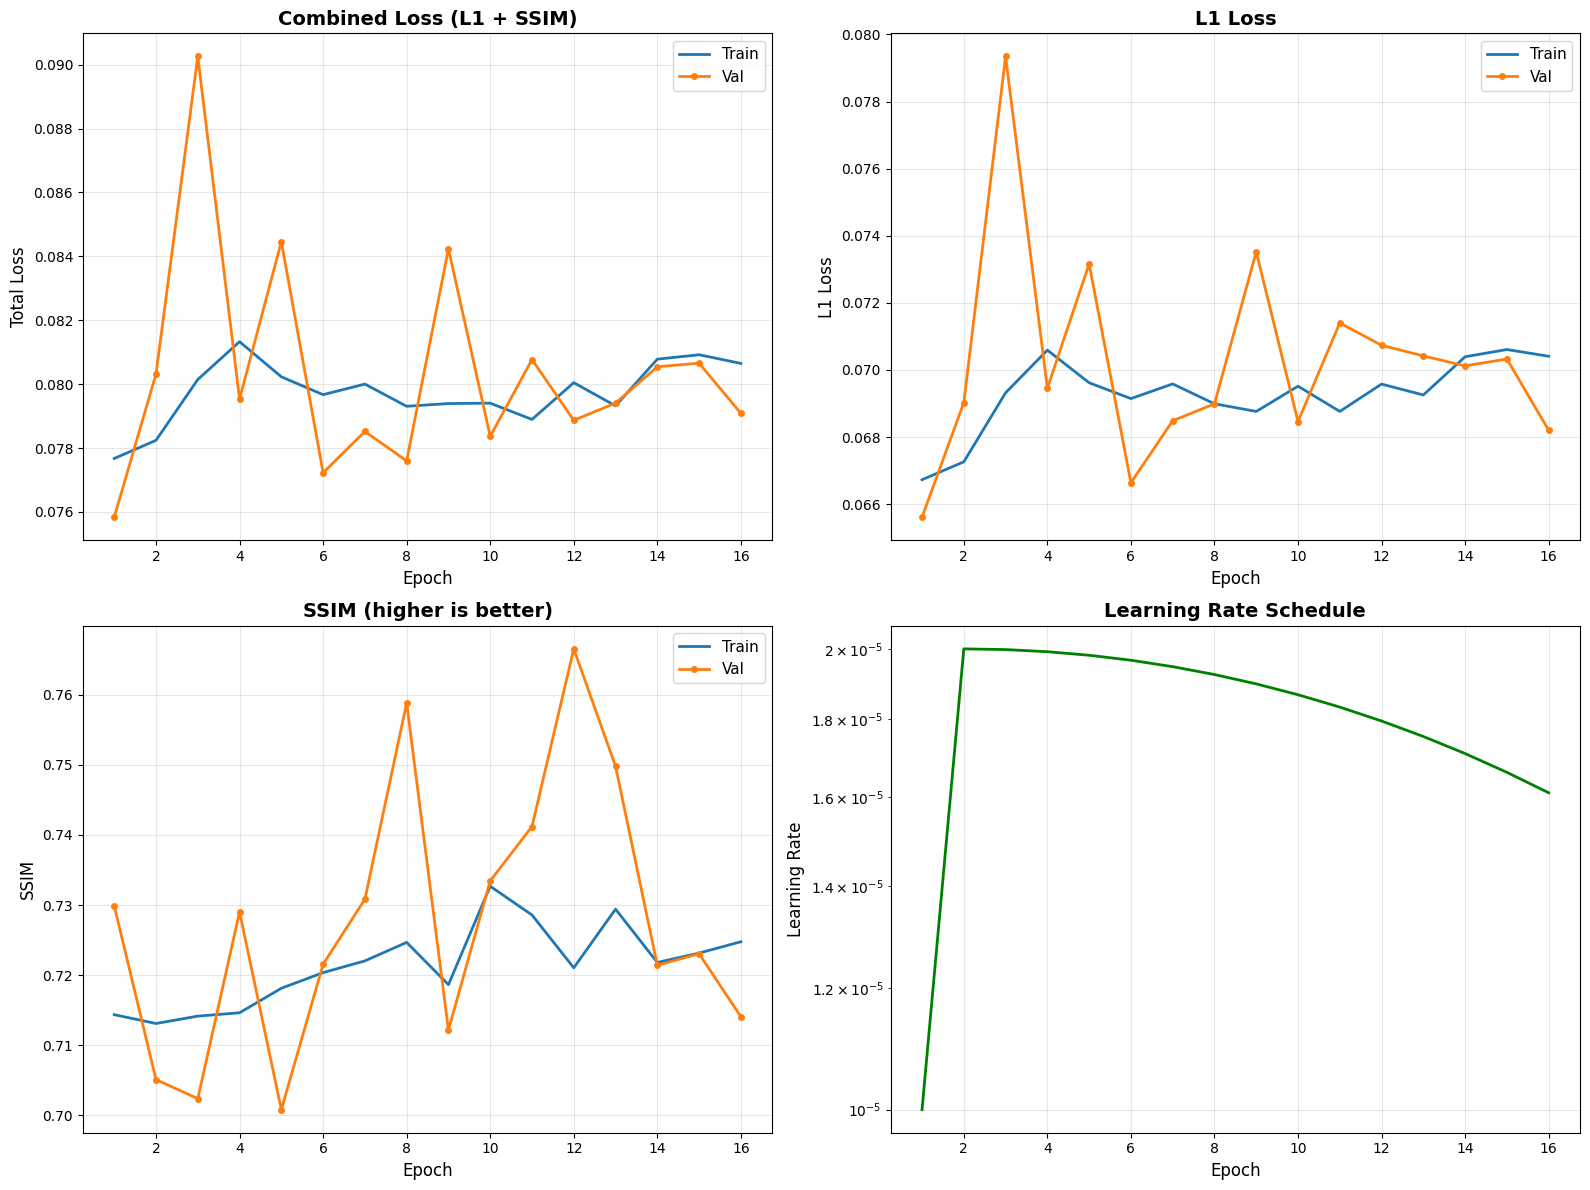

Training curves saved to i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\training_curves.png


In [17]:
plot_training_curves(history=history, save_path=exp_dir / "training_curves.png")
print(f"Training curves saved to {exp_dir / 'training_curves.png'}")

## 10. Test Inference on Validation Samples

Loaded best model from epoch 1


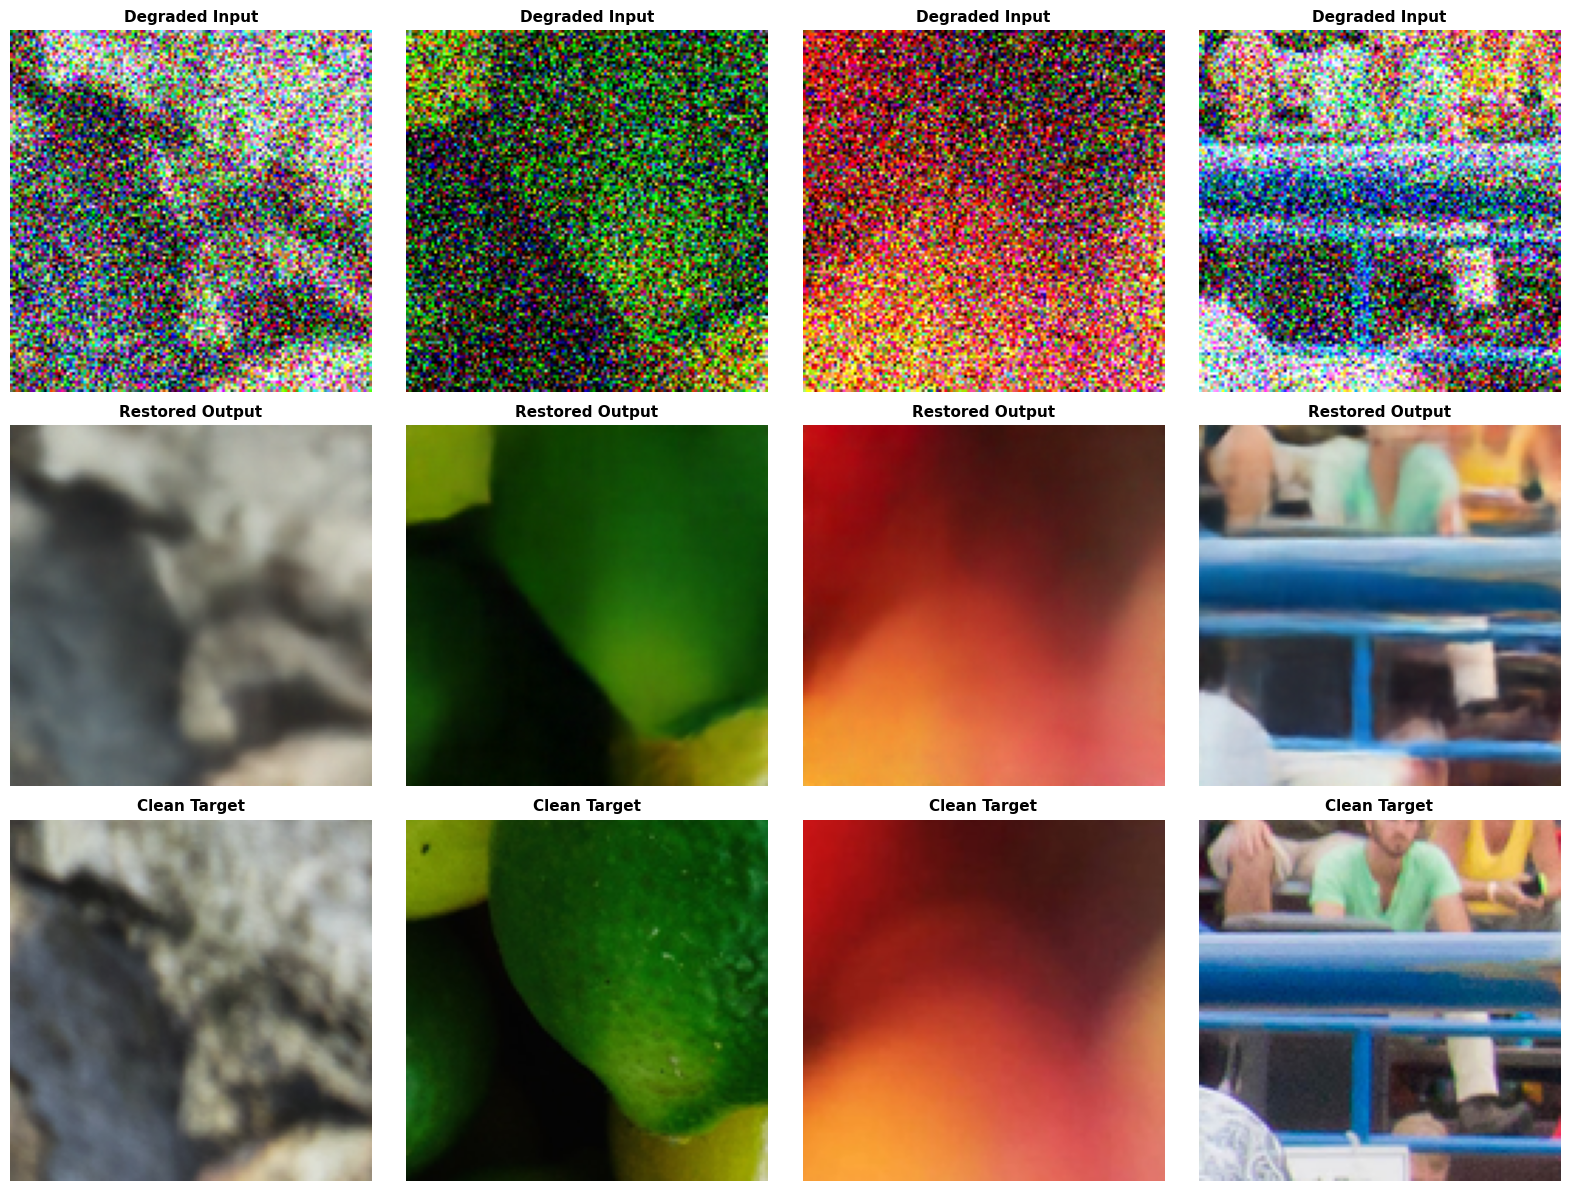

Inference results saved to i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\samples\inference_results.png


In [18]:
checkpoint_info = load_checkpoint(
    checkpoints_dir / "best_model.pth", model=model, device=config["device"]
)
print(f"Loaded best model from epoch {checkpoint_info['epoch']}")

degraded_batch, clean_batch = next(iter(val_loader))
degraded_batch = degraded_batch.to(config["device"])
clean_batch = clean_batch.to(config["device"])

with torch.no_grad():
    restored_batch = model(degraded_batch)

plot_inference_results(
    degraded_batch=degraded_batch,
    restored_batch=restored_batch,
    clean_batch=clean_batch,
    n_samples=4,
    save_path=samples_dir / "inference_results.png",
)

print(f"Inference results saved to {samples_dir / 'inference_results.png'}")

## 11. Summary

In [19]:
print_training_summary(
    history=history,
    best_epoch=best_epoch,
    best_val_loss=best_val_loss,
    exp_dir=exp_dir,
    checkpoints_dir=checkpoints_dir,
    samples_dir=samples_dir,
    logs_dir=logs_dir,
)


📊 TRAINING SUMMARY

Experiment directory: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian

Validation points saved: 16
Best epoch: 1

Best Validation Metrics:
  Loss: 0.0758
  L1: 0.0656
  SSIM: 0.7299

Final Training Metrics:
  Loss: 0.0806
  L1: 0.0704
  SSIM: 0.7248

Performance Statistics:
  Total training time: 0.91h (3276s)
  Total epochs trained: 16
  Avg epoch time: 204.8s
  Avg inference time: 13.4s
  Peak memory: 502MB

Saved files:
  Best model: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\checkpoints\best_model.pth
  Training history: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\history.json
  Training curves: i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\training_curves.png
  I

In [20]:
import importlib
import src.evaluation.inference
import src.evaluation.evaluator

# Ricarichiamo i moduli modificati
importlib.reload(src.evaluation.inference)
importlib.reload(src.evaluation.evaluator)

# Re-importiamo la classe aggiornata
from src.evaluation import ImageRestorationEvaluator


## 12. Quantitative Evaluation on Full-Resolution Images

In [21]:
evaluator = ImageRestorationEvaluator(
    model=model,
    device=config["device"],
    patch_size=config["patch_size"],
    overlap=32,
)

eval_results = evaluator.evaluate_dataset(
    degraded_dir=config["val_degraded_dir"],
    clean_dir=config["val_clean_dir"],
    output_dir=exp_dir / "restored_images",
    save_outputs=True,
    max_images=10,
)

evaluator.print_summary(eval_results)
evaluator.save_results(eval_results, exp_dir / "evaluation_metrics.json")


📊 Evaluating 10 images...


Processing images:   0%|          | 0/10 [00:00<?, ?it/s]


EVALUATION SUMMARY

📊 Evaluated 10 images

📈 Mean Metrics:
   PSNR: 26.36 ± 2.68 dB
   SSIM: 0.7469 ± 0.0767
   MAE: 0.034082 ± 0.012112
   MSE: 0.002841 ± 0.002197

🏆 Best Image (highest PSNR):
   0803.png
   PSNR: 31.57 dB, SSIM: 0.8933

⚠️  Worst Image (lowest PSNR):
   0807.png
   PSNR: 20.40 dB, SSIM: 0.5776


✅ Results saved to i:\Development 2.0\Deep_Learning\Progetto1\Image-Enhancement\experiments\nafnet\gaussian\20260331_160741_nafnet_gaussian\evaluation_metrics.json


## 13. Visualize Full-Resolution Restoration

Best result: 0803.png
PSNR: 31.57 dB, SSIM: 0.8933


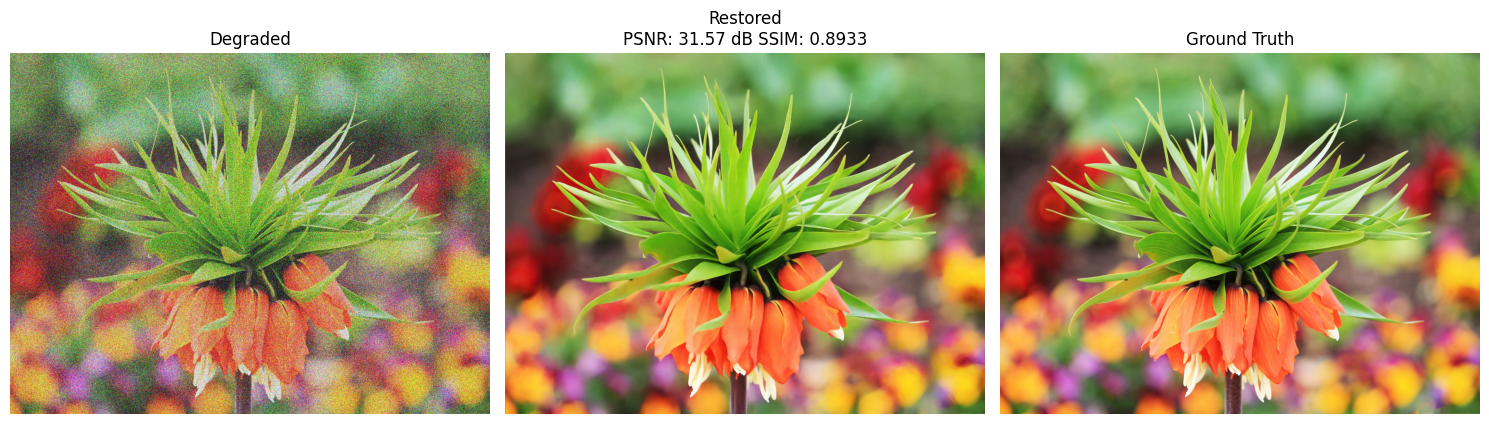

Worst result: 0807.png
PSNR: 20.40 dB, SSIM: 0.5776


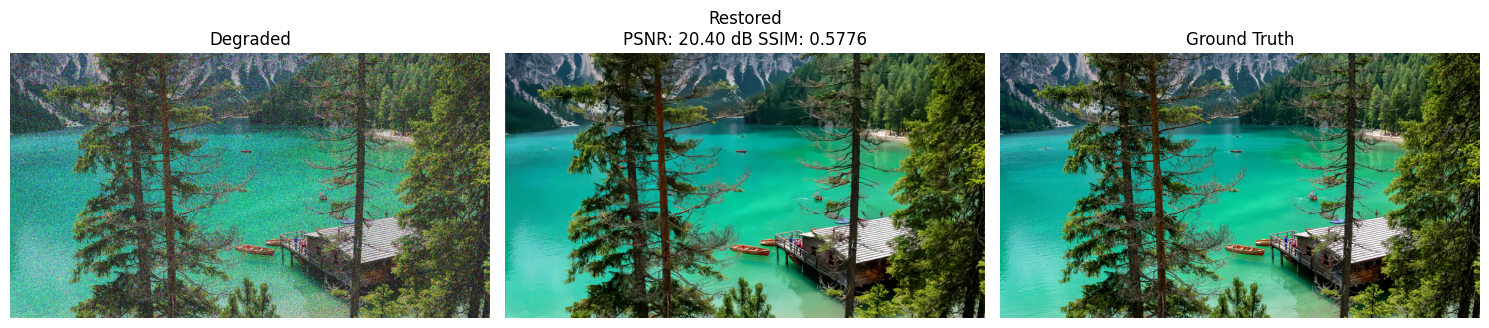

In [22]:
best_img = max(eval_results["per_image"], key=lambda x: x["psnr"])
worst_img = min(eval_results["per_image"], key=lambda x: x["psnr"])

def load_image_trio(filename):
    degraded_path = Path(config["val_degraded_dir"]) / filename
    clean_path = Path(config["val_clean_dir"]) / filename
    restored_path = exp_dir / "restored_images" / filename

    degraded = cv2.cvtColor(cv2.imread(str(degraded_path)), cv2.COLOR_BGR2RGB)
    clean = cv2.cvtColor(cv2.imread(str(clean_path)), cv2.COLOR_BGR2RGB)
    restored = cv2.cvtColor(cv2.imread(str(restored_path)), cv2.COLOR_BGR2RGB)

    return degraded, restored, clean

print(f"Best result: {best_img['filename']}")
print(f"PSNR: {best_img['psnr']:.2f} dB, SSIM: {best_img['ssim']:.4f}")

deg, res, cln = load_image_trio(best_img["filename"])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(deg)
axes[0].set_title("Degraded")
axes[0].axis("off")
axes[1].imshow(res)
axes[1].set_title(f"Restored\nPSNR: {best_img['psnr']:.2f} dB SSIM: {best_img['ssim']:.4f}")
axes[1].axis("off")
axes[2].imshow(cln)
axes[2].set_title("Ground Truth")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(samples_dir / "best_full_restoration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Worst result: {worst_img['filename']}")
print(f"PSNR: {worst_img['psnr']:.2f} dB, SSIM: {worst_img['ssim']:.4f}")

deg, res, cln = load_image_trio(worst_img["filename"])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(deg)
axes[0].set_title("Degraded")
axes[0].axis("off")
axes[1].imshow(res)
axes[1].set_title(f"Restored\nPSNR: {worst_img['psnr']:.2f} dB SSIM: {worst_img['ssim']:.4f}")
axes[1].axis("off")
axes[2].imshow(cln)
axes[2].set_title("Ground Truth")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(samples_dir / "worst_full_restoration.png", dpi=150, bbox_inches="tight")
plt.show()